# Member 3 summary: external data, merchant features, industry growth

This notebook stitches together the outputs of the three modules built for this
project's external-data / feature-engineering track (`external_integration`,
`member3_merchant_features`, `member3_industry_growth`), on top of the already-cleaned ATO dataset
(`external_ato`). It is meant to be read top-to-bottom by a stakeholder who wants the
coverage numbers, the feature definitions, the industry chart, and the limitations in
one place, without digging through four separate `README.md`/`VALIDATION.md` files.

**Scope**: this notebook covers steps 2-4 of this member's assignment (external-data
integration, merchant feature construction, industry growth visualization). It does not
cover fraud analysis or the final merchant ranking/scoring, which are a different
teammate's tasks and consume these outputs as inputs.

Run this notebook from the repository root (or run each module's own `build_*.py`
first if `results/` directories are missing -- see each module's README for the exact
command).

In [1]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "member3_merchant_features").exists() and (ROOT.parent / "member3_merchant_features").exists():
    ROOT = ROOT.parent  # allow running from a notebooks/ subfolder too

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
print("Repo root:", ROOT)

Repo root: /sessions/rcw-012yayq5n9xnibrqls1vebow/mnt/Downloads/project2/MAST30034-Project-2-Group-50


## 1. External data integration (`external_integration/`)

Three ABS/ATO postcode-level sources (Census, SEIFA, ATO) are combined into one dimension table and left-joined onto consumers and transactions by postcode. Full detail: `external_integration/README.md` and `VALIDATION.md`.

In [2]:
ei = ROOT / "external_integration/results"
metadata = json.loads((ei / "metadata.json").read_text())
print(json.dumps(metadata["consumers"], indent=2, default=str))
print(json.dumps(metadata["transactions"], indent=2, default=str))

{
  "input_rows": 499999,
  "output_rows": 499999,
  "unique_ids": 499999,
  "original_columns_unchanged": true,
  "amount_sum_before": null,
  "amount_sum_after": null
}
{
  "input_rows": 14195505,
  "output_rows": 14195505,
  "unique_ids": 14195505,
  "original_columns_unchanged": true,
  "amount_sum_before": "2359703946.3588110473",
  "amount_sum_after": "2359703946.3588110473"
}


In [3]:
consumer_coverage = pd.read_csv(ei / "consumer_coverage.csv")
consumer_coverage

,scope,metric,rows,denominator,rate,matched_amount,total_amount
0,consumer,census_matched,416818,499999,0.833638,NaN,NaN
1,consumer,seifa_matched,416818,499999,0.833638,NaN,NaN
2,consumer,ato_matched,414825,499999,0.829652,NaN,NaN
3,consumer,all_sources_matched,404185,499999,0.808372,NaN,NaN


In [4]:
transaction_coverage = pd.read_csv(ei / "transaction_coverage.csv")
transaction_coverage

,scope,metric,rows,denominator,rate,matched_amount,total_amount,amount_coverage_rate
0,transaction,census_matched,11855228,14195505,0.835140,1.970934e+09,2.359704e+09,0.835246
1,transaction,seifa_matched,11855228,14195505,0.835140,1.970934e+09,2.359704e+09,0.835246
2,transaction,ato_matched,11760045,14195505,0.828434,1.954771e+09,2.359704e+09,0.828397
3,transaction,all_sources_matched,11466314,14195505,0.807743,1.905898e+09,2.359704e+09,0.807685


### Coverage is not geographically uniform

A review of the first version of this analysis pointed out that a similar row-count vs. amount-weighted coverage rate only shows the two groups have similar *average* transaction size -- it says nothing about whether coverage is uniform across other dimensions such as state. It isn't. *(A second review found this table and the one below had no generation code anywhere in the pipeline -- they're now produced by `external_integration/integrate.py`'s own `write_transaction_diagnostics()`, called from its `run()`, so a teammate re-running the pipeline from raw data gets them for free; see `external_integration/VALIDATION.md`.)*

In [5]:
coverage_by_state = pd.read_csv(ei / "transaction_coverage_by_state.csv")
coverage_by_state.style.format({"all_sources_matched_rate": "{:.1%}"})

,consumer_state,transactions,matched_transactions,all_sources_matched_rate
0,SA,1612955,1518522,94.1%
1,TAS,525947,487125,92.6%
2,QLD,2100381,1944152,92.6%
3,VIC,3280823,2981054,90.9%
4,ACT,130325,107931,82.8%
5,NT,202178,139743,69.1%
6,WA,2247663,1535974,68.3%
7,NSW,4095233,2751813,67.2%


NSW, WA and NT have external-data coverage roughly 20-25 percentage points below VIC/QLD/SA/TAS. Any downstream analysis that slices by state (or by a merchant's typical customer state) should keep this in mind: a lower regional-feature coverage for a NSW/WA/NT-heavy merchant reflects a data gap, not necessarily a less important customer base.

By contrast, the amount distribution is genuinely similar between matched and unmatched transactions (this part of the original claim holds up):

In [6]:
amount_by_match = pd.read_csv(ei / "transaction_amount_by_match_status.csv")
amount_by_match

,all_sources_matched,n,p25,p50,p75,p99,mean
0,False,2729191,26.169281,62.200941,150.426707,1614.791920,166.278522
1,True,11466314,26.120159,62.238027,150.456028,1620.512424,166.217156


### A map, not just tables (`external_integration/postcode_map/`)

Everything above is a table -- coverage %, missingness counts, feature values. This section adds an actual geospatial view: Australia's postcodes coloured by ABS SEIFA 2021 IRSD national decile (1 = most disadvantaged, 10 = least disadvantaged), joined from this project's own `external_postcode_features.csv` onto real ABS ASGS Ed.3 POA (2021) postcode boundary polygons, with Sydney/Melbourne/Brisbane/Perth insets since national scale hides small inner-city postcodes. The join matches 2,475 of 2,513 boundary polygons (98.5%) -- see `postcode_map/README.md` for why the rest don't match (mostly PO-box-only postcodes with a statistical record but no physical delivery-area boundary, or the reverse) and how to reproduce the map.

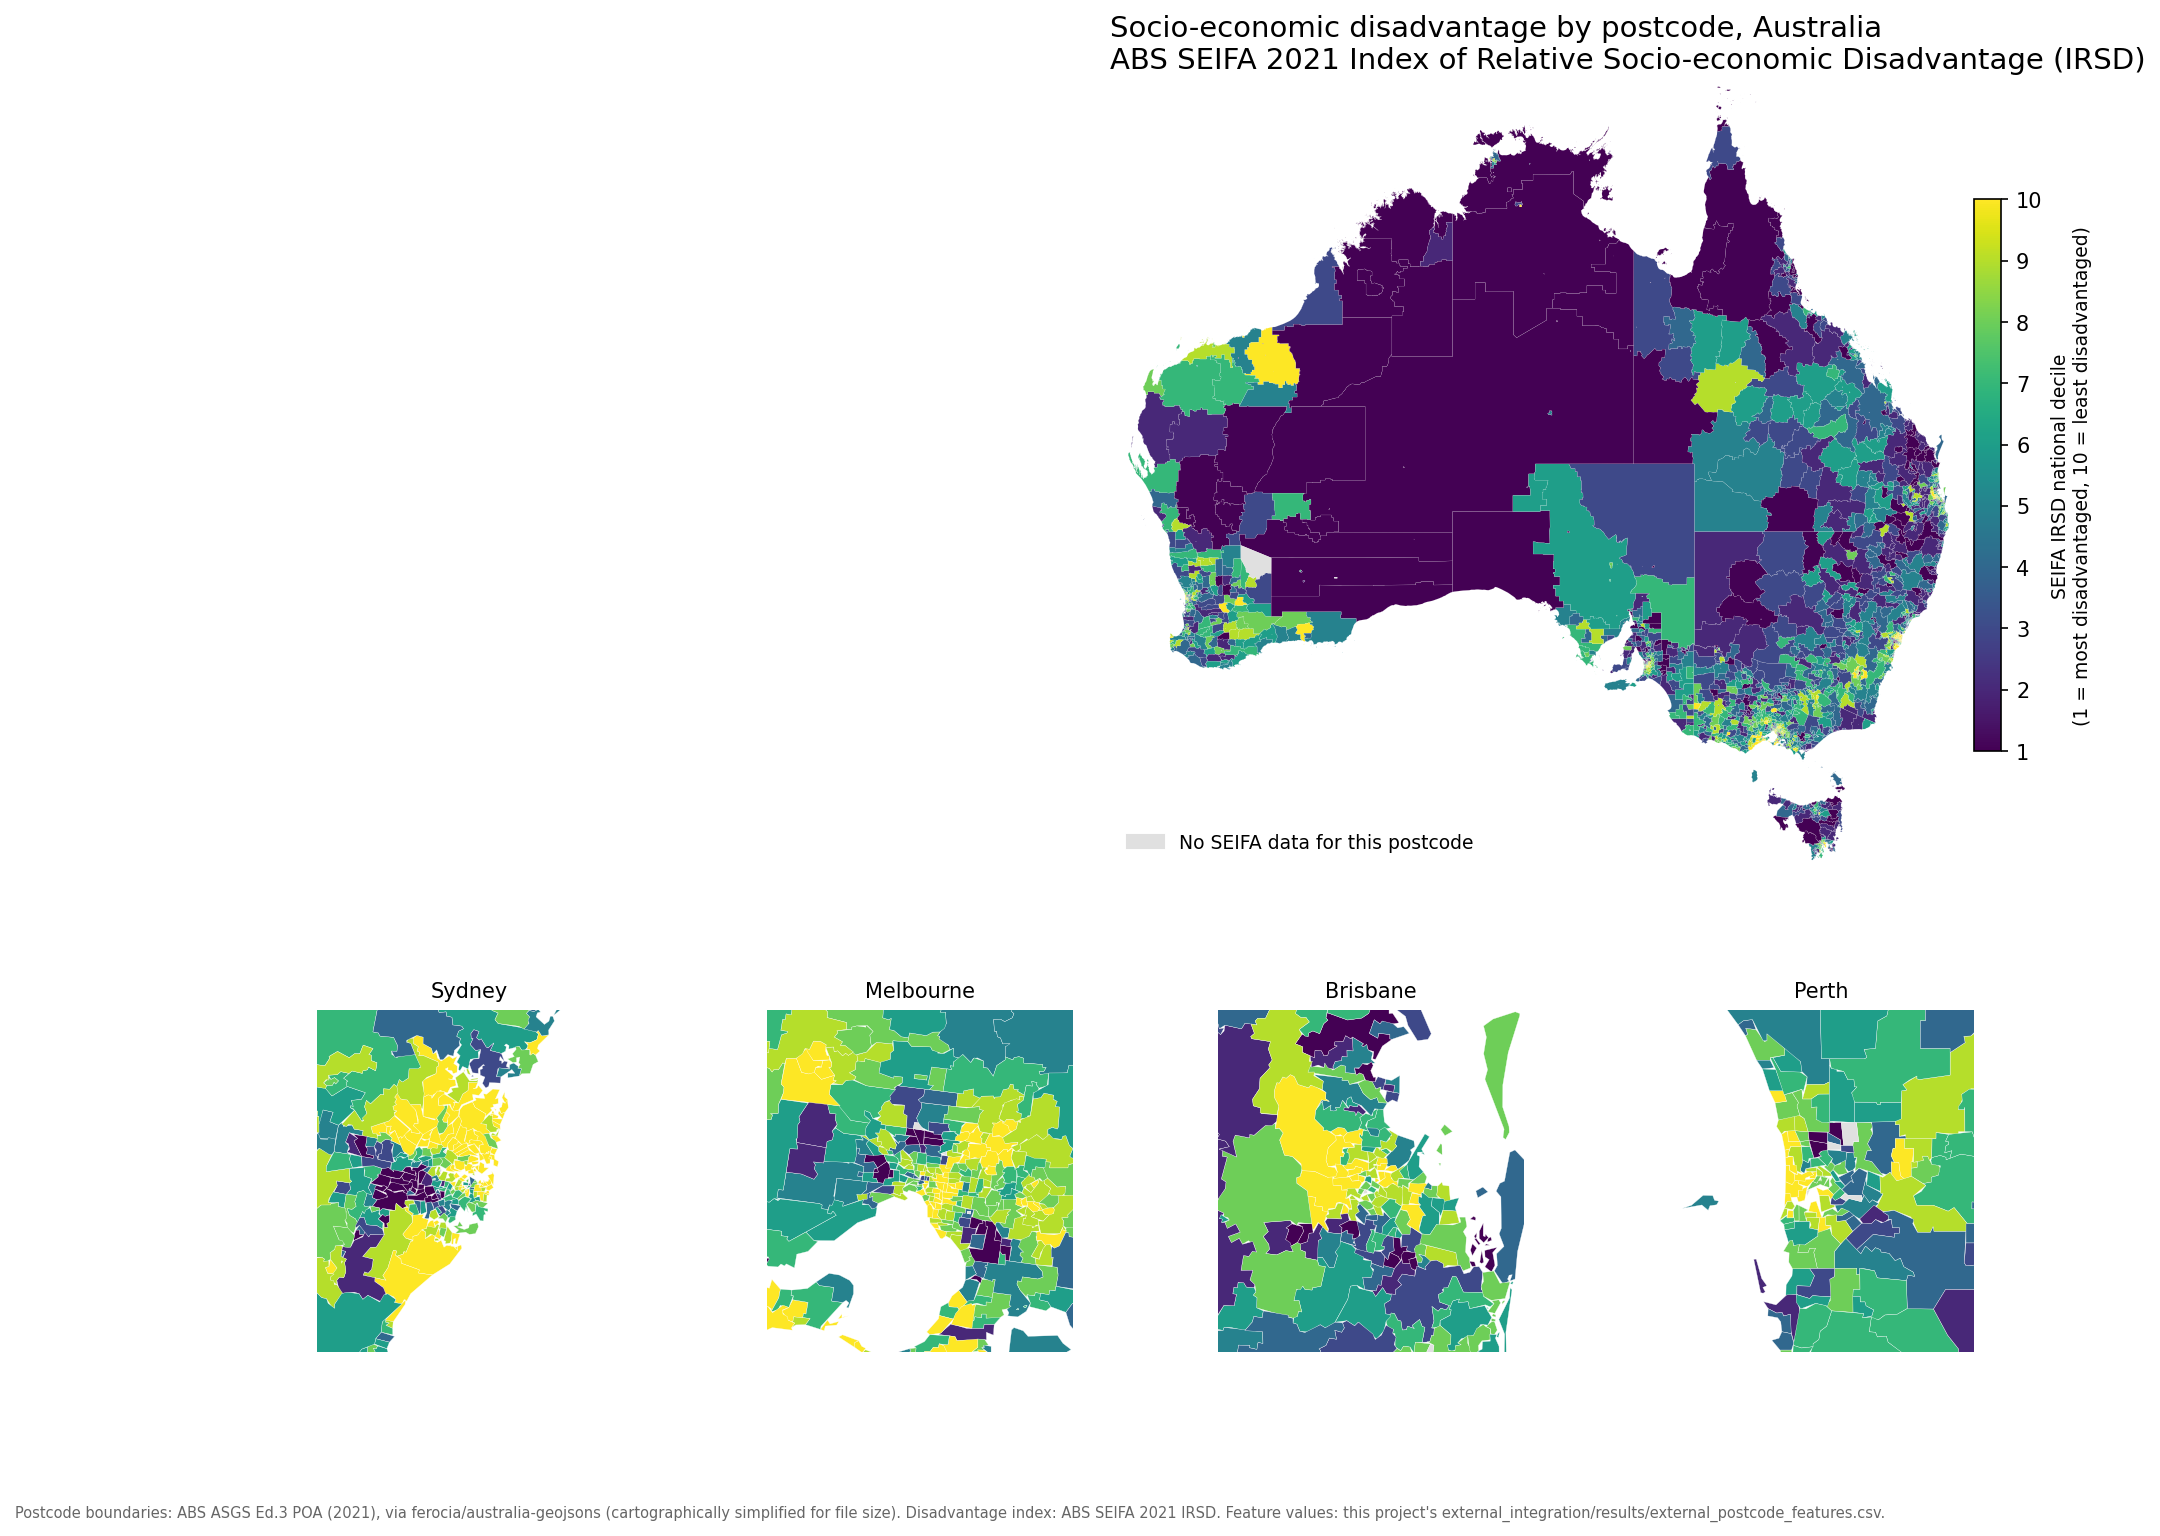

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "external_integration/postcode_map/results/postcode_socioeconomic_map.png")))

## 2. Merchant features (`member3_merchant_features/`)

One row per merchant (transaction scale, average order value, repeat rate, revenue trend & stability, regional/socio-economic profile, category/pricing/take rate). Full detail: `member3_merchant_features/README.md` and `VALIDATION.md`.

In [8]:
mf_dir = ROOT / "member3_merchant_features/results"
merchant_features = pd.read_parquet(mf_dir / "merchant_features.parquet")
print(f"{len(merchant_features):,} merchants x {merchant_features.shape[1]} columns")
merchant_features.head(3)

4,422 merchants x 46 columns


,merchant_abn,merchant_name,merchant_category,merchant_pricing_level,merchant_take_rate_pct,has_merchant_master_record,total_transactions,total_revenue,avg_transaction_value,unique_consumers,repeat_consumer_share,first_order_date,last_order_date,active_months_all_time,potential_months_in_window,active_months_in_window,transactions_in_window,normalized_monthly_revenue_trend,monthly_revenue_cv,low_sample_short_window,low_sample_few_transactions,low_sample_few_active_months,low_sample_growth_estimate,estimated_bnpl_revenue,regional_data_coverage_rate_all_sources,census_data_coverage_rate,seifa_data_coverage_rate,ato_data_coverage_rate,regional_data_coverage_rate_all_sources_by_count,census_data_coverage_rate_by_count,seifa_data_coverage_rate_by_count,ato_data_coverage_rate_by_count,ato_small_denominator_share_of_matched,census_population,census_median_household_income_weekly,census_avg_household_size,census_single_parent_family_share,census_couple_with_children_family_share,census_unemployment_rate_published_pct,census_labour_force_participation_rate_published_pct,seifa_irsd_national_decile,seifa_irsad_national_decile,seifa_ier_national_decile,ato_taxable_income_or_loss_per_reporter,ato_salary_or_wages_per_recipient,ato_net_tax_payer_share
0,10023283211,Felis Limited,"furniture, home furnishings and equipment shop...",E,0.18,True,3261,703277.711451,215.663205,3032,0.071900,2021-02-28,2022-10-26,21,19,19,3073,0.018779,0.183963,False,False,False,False,1265.899881,0.809986,0.830325,0.830325,0.828978,0.806808,0.829807,0.829807,0.829193,0.101701,9591.873245,1598.090540,2.462574,0.137732,0.396714,4.545196,59.159350,5.426345,5.412987,5.455659,68260.371739,63998.111541,0.734878
1,10142254217,Arcu Ac Orci Corporation,"cable, satellite, and other pay television and...",B,4.22,True,3036,118356.146073,38.984238,2849,0.063882,2021-02-28,2022-10-26,21,19,19,2827,0.012203,0.200024,False,False,False,False,4994.629364,0.804973,0.829502,0.829502,0.828275,0.811265,0.837945,0.837945,0.833333,0.096047,9638.110063,1609.036557,2.466890,0.137717,0.397312,4.618711,59.135731,5.512892,5.524395,5.500595,69361.310505,64617.995761,0.734825
2,10165489824,Nunc Sed Company,"jewelry, watch, clock, and silverware shops",B,4.40,True,5,56180.473857,11236.094771,5,0.000000,2021-11-30,2022-09-18,5,11,5,5,-0.093673,1.440343,False,True,False,True,2471.940850,0.632668,0.632668,0.632668,0.632668,0.800000,0.800000,0.800000,0.800000,0.250000,5728.750000,1855.250000,2.700000,0.114423,0.490410,4.150000,63.625000,8.250000,8.000000,8.500000,76144.193842,63913.702304,0.782871


### Field definitions

The full data dictionary (one row per column, with its definition, unit and source):

In [9]:
data_dictionary = pd.read_csv(mf_dir / "data_dictionary.csv")
data_dictionary

,field,definition,unit,source
0,merchant_abn,Australian Business Number of the merchant; pr...,id,derived
1,merchant_name,"Merchant trading name, from tbl_merchants",string,derived
2,merchant_category,One of 25 categories parsed from tbl_merchants...,category,derived
3,merchant_pricing_level,Pricing/risk tier parsed from tbl_merchants.ta...,category A-E,derived
4,merchant_take_rate_pct,BNPL take rate parsed from tbl_merchants.tags,percent,derived
5,has_merchant_master_record,False for merchant_abn seen in transactions bu...,boolean,derived
6,total_transactions,Count of curated transactions for this merchan...,count,derived
7,total_revenue,Sum of dollar_value across this merchant's cur...,AUD,derived
8,avg_transaction_value,"total_revenue / total_transactions, all time",AUD,derived
9,unique_consumers,"Distinct consumer_id count for this merchant, ...",count,derived


### Revenue trend & stability: read this carefully

`normalized_monthly_revenue_trend` is a **normalised regression slope** (`regr_slope / regr_avgy` over a fixed full-month window, 2021-03 to 2022-09, with months of no activity counted as zero revenue rather than skipped) -- it is **not** a month-over-month growth percentage. A review of an earlier version (which used every month a merchant had *any* activity, including two partial calendar months, and silently skipped zero-revenue months) found the trend's sign flipped for 253 of 4,405 merchants once restricted to full months, and a top-100-by-trend selection only overlapped 74/100 between the two versions. The current, fixed version's median trend (0.0144) matches the reviewer's independent recomputation.

**Low-sample flag, split in three (second + third review).** The original single check (calendar span < 3 months) missed merchants with very few actual transactions or few active months whenever their span happened to be long -- e.g. 187 merchants with fewer than 10 total transactions, and 29 with only 1-2 active months, went unflagged. It's now three independent flags -- `low_sample_short_window`, `low_sample_few_transactions`, `low_sample_few_active_months` (<3 active months) -- with `low_sample_growth_estimate` true if any of them is. A third review then found `low_sample_few_transactions` must use `transactions_in_window` (<10, transactions actually inside the growth window), not `total_transactions` (all-time): 18 merchants had 10-12 transactions all-time but only 8-9 inside the window, so the all-time count missed them. These thresholds are this team's own judgment call; see `member3_merchant_features/results/low_sample_threshold_comparison.csv` for how alternates change the count.

In [10]:
print("Median normalized_monthly_revenue_trend:", merchant_features["normalized_monthly_revenue_trend"].median().round(4))
print("Merchants flagged low-sample (any of the three criteria):", int(merchant_features["low_sample_growth_estimate"].sum()))
print(merchant_features[["low_sample_short_window", "low_sample_few_transactions", "low_sample_few_active_months"]].sum())
print("transactions_in_window vs total_transactions can differ:",
      int(((merchant_features['transactions_in_window'] < 10) & (merchant_features['total_transactions'] >= 10)).sum()),
      "merchants pass the all-time count but fail the windowed one")
merchant_features[["total_revenue", "normalized_monthly_revenue_trend", "monthly_revenue_cv", "potential_months_in_window", "low_sample_growth_estimate"]].describe()

Median normalized_monthly_revenue_trend: 0.0144
Merchants flagged low-sample (any of the three criteria): 220
low_sample_short_window          15
low_sample_few_transactions     220
low_sample_few_active_months     44
dtype: int64
transactions_in_window vs total_transactions can differ: 18 merchants pass the all-time count but fail the windowed one


,total_revenue,normalized_monthly_revenue_trend,monthly_revenue_cv,potential_months_in_window
count,4.422000e+03,4407.000000,4407.000000,4422.000000
mean,5.336282e+05,0.010755,0.509367,18.592944
std,1.205417e+06,0.047980,0.440978,1.777062
min,1.004524e+04,-0.857143,0.133836,1.000000
25%,3.698828e+04,0.006692,0.220862,19.000000
50%,1.414770e+05,0.014357,0.333060,19.000000
75%,6.426694e+05,0.020662,0.615013,19.000000
max,9.857402e+06,0.655191,3.872983,19.000000


### Regional feature coverage is reported per source -- by amount AND by row count

Census, SEIFA and ATO are matched independently, so a single blended coverage figure hides which specific columns are how reliable. A second review found the amount-weighted coverage rate can look far higher than the data actually backing a merchant's regional feature AVERAGES, since those averages are row-count-weighted (one large matched transaction among many small unmatched ones inflates the amount-weighted figure). Measured gap for individual merchants, ATO: up to **41.35 percentage points**. The `_by_count` columns below are row-count-weighted and are the primary figure for explaining reliability; the plain columns (amount-weighted) are kept for reference.

In [11]:
merchant_features[["census_data_coverage_rate_by_count", "seifa_data_coverage_rate_by_count",
                    "ato_data_coverage_rate_by_count", "regional_data_coverage_rate_all_sources_by_count",
                    "census_data_coverage_rate", "seifa_data_coverage_rate",
                    "ato_data_coverage_rate", "regional_data_coverage_rate_all_sources"]].mean().to_frame("fleet_average_coverage")

,fleet_average_coverage
census_data_coverage_rate_by_count,0.834247
seifa_data_coverage_rate_by_count,0.834247
ato_data_coverage_rate_by_count,0.826960
regional_data_coverage_rate_all_sources_by_count,0.806053
census_data_coverage_rate,0.835096
seifa_data_coverage_rate,0.835096
ato_data_coverage_rate,0.827204
regional_data_coverage_rate_all_sources,0.806413


`feature_nonnull_rate_when_matched.csv` also checks that \"postcode matched\" actually means \"field usable\" (it isn't automatic -- a suppressed/undefined derived ratio can still be null even when its source matched):

In [12]:
pd.read_csv(mf_dir / "feature_nonnull_rate_when_matched.csv")

,field,source,transactions_with_source_matched,transactions_with_source_matched_and_field_nonnull,nonnull_rate_when_matched
0,census_population,census,11855228,11855228,1.000000
1,census_median_household_income_weekly,census,11855228,11855228,1.000000
2,census_avg_household_size,census,11855228,11832803,0.998108
3,census_single_parent_family_share,census,11855228,11753229,0.991396
4,census_couple_with_children_family_share,census,11855228,11753229,0.991396
5,census_unemployment_rate_published_pct,census,11855228,11855228,1.000000
6,census_labour_force_participation_rate_publish...,census,11855228,11855228,1.000000
7,seifa_irsd_national_decile,seifa,11855228,11766161,0.992487
8,seifa_irsad_national_decile,seifa,11855228,11766161,0.992487
9,seifa_ier_national_decile,seifa,11855228,11766161,0.992487


### Merchants with no `tbl_merchants` master record

396 of 4,422 merchants seen in transactions have no category/pricing-level/take-rate (kept in the table, flagged, not silently dropped or silently imputed):

In [13]:
orphans = merchant_features[~merchant_features["has_merchant_master_record"]]
print(f"{len(orphans)} merchants with no master record ({len(orphans) / len(merchant_features):.1%} of all merchants)")
orphans[["merchant_abn", "total_transactions", "total_revenue"]].describe()

396 merchants with no master record (9.0% of all merchants)


,total_transactions,total_revenue
count,396.000000,3.960000e+02
mean,1466.742424,5.117378e+05
std,7450.404659,1.060569e+06
min,1.000000,1.004524e+04
25%,18.000000,4.188000e+04
50%,79.000000,1.522815e+05
75%,454.500000,7.035924e+05
max,116773.000000,8.745124e+06


## 3. Industry growth (`member3_industry_growth/`)

Merchants are grouped into the project's 5 agreed industry groups (plus an Unclassified audit bucket) and revenue trends are visualized for this dataset's sample merchants. Full detail: `member3_industry_growth/README.md` and `VALIDATION.md`.

In [14]:
ig_dir = ROOT / "member3_industry_growth/results"
summary = pd.read_csv(ig_dir / "industry_growth_summary.csv")
summary.style.format({"total_revenue": "{:,.0f}", "revenue_share": "{:.1%}",
                        "normalized_monthly_revenue_trend": "{:.4f}", "monthly_revenue_cv": "{:.3f}"})

,industry_group,total_revenue,total_transactions,max_active_merchants_in_a_month,normalized_monthly_revenue_trend,monthly_revenue_cv,revenue_share,n_merchants
0,"Home, Garden & Living","491,071,546",3389533.000000,791,0.0147,0.181,22.0%,827
1,"Creative, Books & Leisure","421,972,386",1506792.000000,807,0.0147,0.183,18.9%,827
2,"Digital, Technology & Communications","413,788,401",3325992.000000,850,0.0147,0.183,18.5%,867
3,"Mobility, Health & Specialist Services","383,097,623",2512066.000000,792,0.0149,0.182,17.1%,806
4,"Art, Gifts, Jewellery & Fashion","332,694,503",2156436.000000,604,0.0141,0.180,14.9%,699
5,Unclassified,"191,916,936",549947.000000,333,0.0150,0.194,8.6%,396


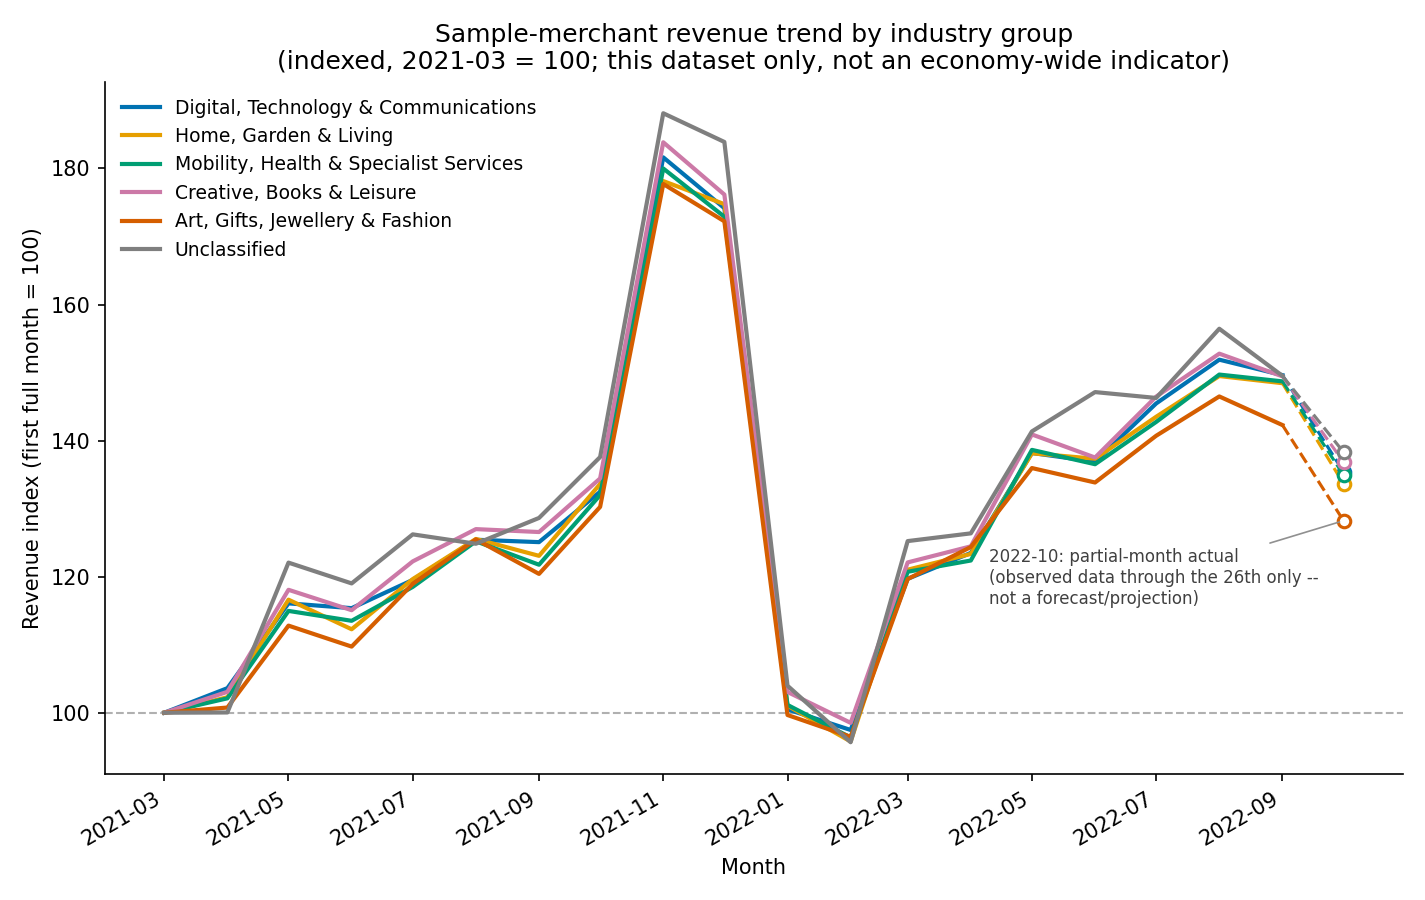

In [15]:
from IPython.display import Image, display
display(Image(filename=str(ig_dir / "charts/industry_growth_indexed.png")))

### Why October 2022's month-total looks lower on the chart

The data ends 2022-10-26, so October has only 26 of 31 days. Left in as an ordinary month, its **total** revenue looks like an 8-10% decline from September -- but its **average daily** revenue is actually 3.9-6.7% *higher* than September's for every group. **Calibrated conclusion (revised after a second review found the first version overclaimed):** October's total is affected by incomplete observation and cannot be directly read as a business decline; the OBSERVED daily average during this period is higher. What a complete October would have shown is unknown -- this is not a claim that there was no decline, only that the month-total figure alone cannot support one. The chart above shows October as a separate point labelled \"partial-month actual\" (an actual observation, not a forecast/projection) rather than an ordinary data point for exactly this reason; the chart below makes the daily-average comparison visible:

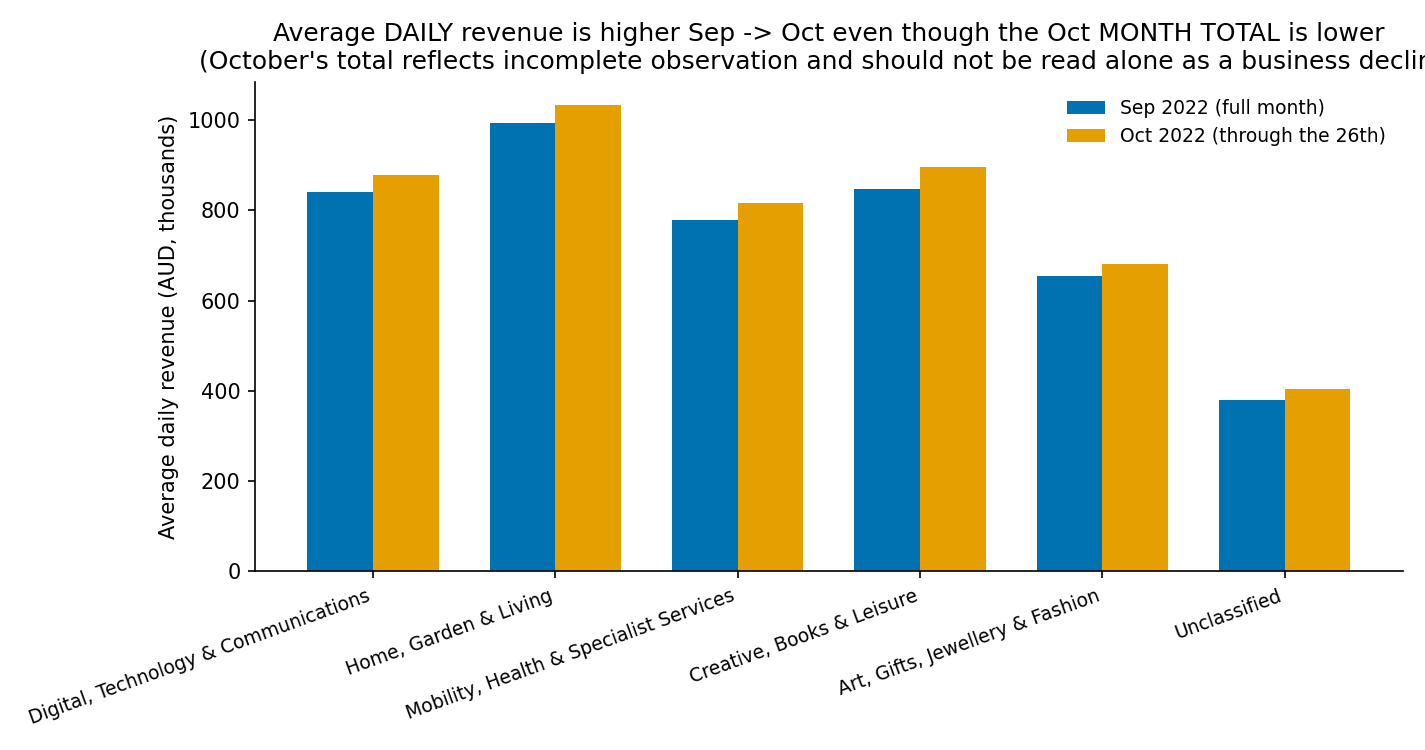

In [16]:
display(Image(filename=str(ig_dir / "charts/industry_sep_vs_oct_daily_avg.png")))

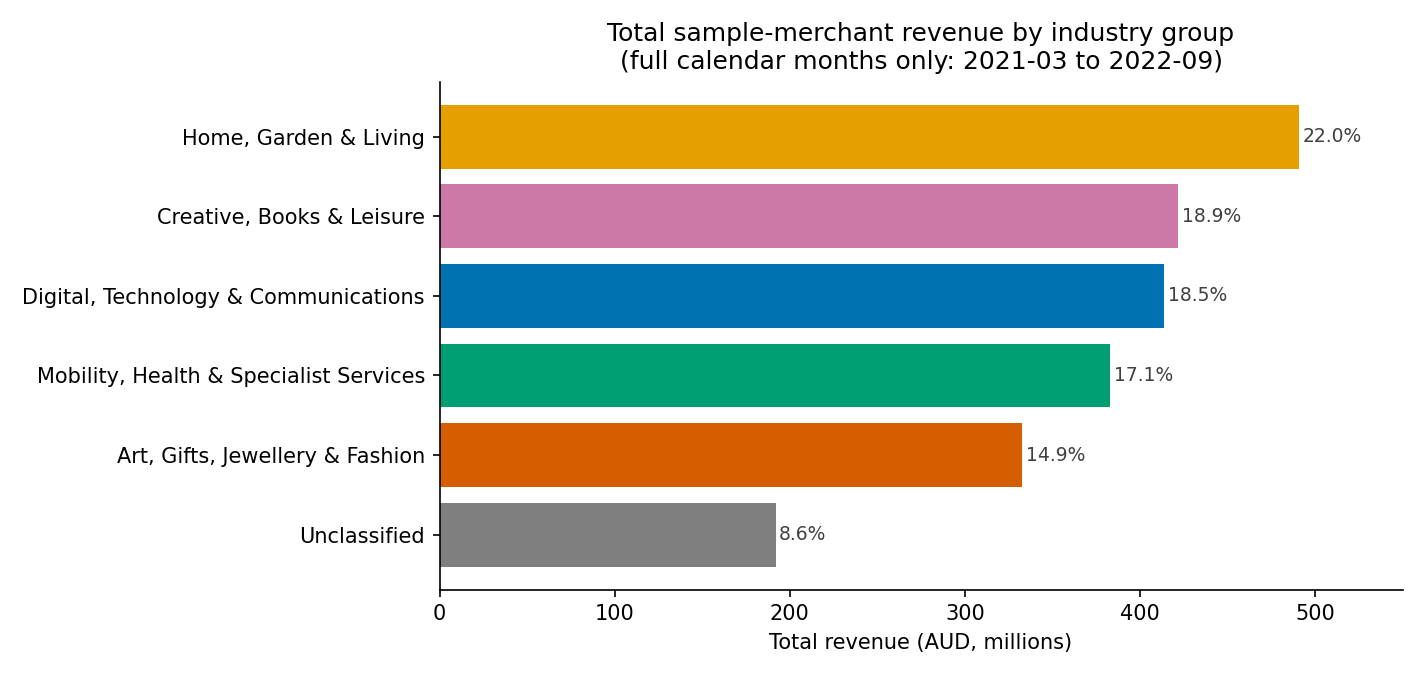

In [17]:
display(Image(filename=str(ig_dir / "charts/industry_revenue_share.png")))

## 4. Limitations and assumptions

- **Sample scope only.** Every figure in `member3_industry_growth` and `member3_merchant_features` describes this project's provided dataset (a fixed set of merchants and a synthetically generated transaction history) -- none of it is a claim about the whole Australian retail industry or an ABS-comparable statistic.
- **External data is retrospective and not perfectly matched.** Census/SEIFA (2021) and ATO (2021-22) are different reference years reconciled onto one postcode key; roughly 19-20% of consumer/transaction rows don't match all three sources, and that non-match rate is markedly higher in NSW, WA and NT than elsewhere (Section 1).
- **The 5-industry-group mapping is the team's own judgment call**, not an official ANZSIC/MCC industry-group standard, reconstructed here from an agreed merchant-count breakdown (see `member3_industry_growth/README.md` for the full 25-category mapping and to flag any category you'd place differently).
- **396 merchants have no master-table record** (category/pricing/take-rate unavailable) and are kept for audit but may need a separate inclusion/exclusion rule in the final ranking.
- **220 merchants have a low-sample revenue-trend estimate** (flagged by any of three independent criteria: short observation window, few transactions inside the growth window, or few active months -- see Section 2) -- their trend/CV should not be used in a ranking without care, and the trend/CV is null outright for the 15 with a short-window flag.
- **ATO small-denominator postcodes.** `ato_small_denominator_share_of_matched` surfaces how much of a merchant's ATO-derived features rest on postcodes with fewer than 100 individuals behind the ratio (fleet mean ~9.7%) -- higher values mean less statistically stable ATO features for that merchant.
- **Regional features are transaction-weighted averages, not merchant-declared attributes.** They describe where a merchant's *observed order volume* came from in this dataset, not an independent survey of its customer base.
- **This notebook and its three source modules do not perform fraud analysis or final merchant scoring/ranking** -- those consume `merchant_features.parquet` and `member3_industry_growth`'s outputs as inputs but are a different teammate's work.